# EDA — Healthcare Dataset

This notebook performs exploratory data analysis (EDA) on the dataset at `../dataset/Healthcare_Dataset.csv`. Run the cells to reproduce summaries, plots, and initial insights.

In [1]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.options.display.max_columns = 60

In [2]:
# Load dataset

df = pd.read_csv('../dataset/Healthcare_Dataset.csv')
print('Rows, columns:', df.shape)
df.head()

Rows, columns: (1000, 18)


,PatientID,PatientName,Age,Gender,Diagnosis,Hospital,Department,Doctor,InsuranceType,City,State,AdmissionDate,DischargeDate,LengthOfStay,Cost,BillingAmount,Outcome,Readmission30Days
0,PID1,Noah Singh,88,Female,Heart Failure,Chennai General Hospital,Orthopedics,Dr. Patel,Medicaid,Detroit,MI,5/31/2024,6/11/2024,11,2679,4623,Deceased,No
1,PID2,Liam Patel,19,Male,Stroke,Royal Women’s Hospital,Cardiology,Dr. Johnson,Medicare,Ann Arbor,MI,1/23/2024,2/3/2024,11,6282,9577,Improved,Yes
2,PID3,Liam Patel,56,Female,Infection,Michigan Health Center,Orthopedics,Dr. Johnson,Private,Detroit,TX,8/9/2024,8/23/2024,14,4468,5929,Transferred,Yes
3,PID4,Noah Singh,7,Male,Arthritis,Michigan Health Center,Pediatrics,Dr. Kumar,Medicare,Chennai,NY,11/5/2024,11/7/2024,2,7981,8822,Recovered,No
4,PID5,Aarav Kumar,38,Male,Asthma,Chennai General Hospital,Neurology,Dr. Patel,Self-Pay,Ann Arbor,TN,8/20/2024,8/29/2024,9,6318,10235,Recovered,Yes


In [14]:
# Summary statistics


df.describe(include='all')

    

,PatientID,PatientName,Age,Gender,Diagnosis,Hospital,Department,Doctor,InsuranceType,City,State,AdmissionDate,DischargeDate,LengthOfStay,Cost,BillingAmount,Outcome,Readmission30Days,calc_los,age_group
count,1000,1000,1000.000000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000.000000,1000.000000,1000.000000,1000,1000,1000.000000,1000
unique,1000,6,NaN,2,10,5,5,5,4,5,5,NaN,NaN,NaN,NaN,NaN,4,2,NaN,6
top,PID1000,Noah Singh,NaN,Female,Infection,Detroit Lakes Medical,Emergency,Dr. Johnson,Private,Ann Arbor,CA,NaN,NaN,NaN,NaN,NaN,Recovered,Yes,NaN,0-18
freq,1,178,NaN,502,115,224,215,208,258,226,216,NaN,NaN,NaN,NaN,NaN,257,507,NaN,193
mean,NaN,NaN,46.274000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-06-27 07:07:40.800000,2024-07-05 07:53:45.600000,8.032000,6867.746000,9166.305000,NaN,NaN,8.032000,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 00:00:00,2024-01-03 00:00:00,1.000000,2003.000000,2824.000000,NaN,NaN,1.000000,NaN
25%,NaN,NaN,23.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-04-01 00:00:00,2024-04-08 00:00:00,4.000000,4377.000000,6606.250000,NaN,NaN,4.000000,NaN
50%,NaN,NaN,47.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-06-19 00:00:00,2024-06-27 00:00:00,8.000000,6833.500000,9133.000000,NaN,NaN,8.000000,NaN
75%,NaN,NaN,69.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-09-22 00:00:00,2024-09-30 00:00:00,12.000000,9427.750000,11648.500000,NaN,NaN,12.000000,NaN
max,NaN,NaN,90.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-30 00:00:00,2025-01-12 00:00:00,15.000000,11981.000000,15649.000000,NaN,NaN,15.000000,NaN


In [15]:
# Missing values


df.isnull().sum().sort_values(ascending=False)

    

PatientID            0
PatientName          0
Age                  0
Gender               0
Diagnosis            0
Hospital             0
Department           0
Doctor               0
InsuranceType        0
City                 0
State                0
AdmissionDate        0
DischargeDate        0
LengthOfStay         0
Cost                 0
BillingAmount        0
Outcome              0
Readmission30Days    0
calc_los             0
age_group            0
dtype: int64

In [ ]:
# Convert dates and derive LOS where possible


for col in ['AdmissionDate','DischargeDate']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

if 'AdmissionDate' in df.columns and 'DischargeDate' in df.columns:
    df['calc_los'] = (df['DischargeDate'] - df['AdmissionDate']).dt.days
    mismatch = ((df['calc_los'].notna()) & (df['LengthOfStay'].notna()) & (df['calc_los'] != df['LengthOfStay'])).sum()
    print('Calculated LOS mismatches:', mismatch)

df['LengthOfStay'] = pd.to_numeric(df['LengthOfStay'], errors='coerce')

    

Calculated LOS mismatches: 0


In [16]:
# Top diagnoses


diag_counts = df['Diagnosis'].value_counts().head(15)
diag_counts

    

Diagnosis
Infection        115
Heart Failure    105
Diabetes         102
Arthritis        102
Hypertension     102
Fracture         100
Pneumonia         97
Asthma            96
Migraine          91
Stroke            90
Name: count, dtype: int64

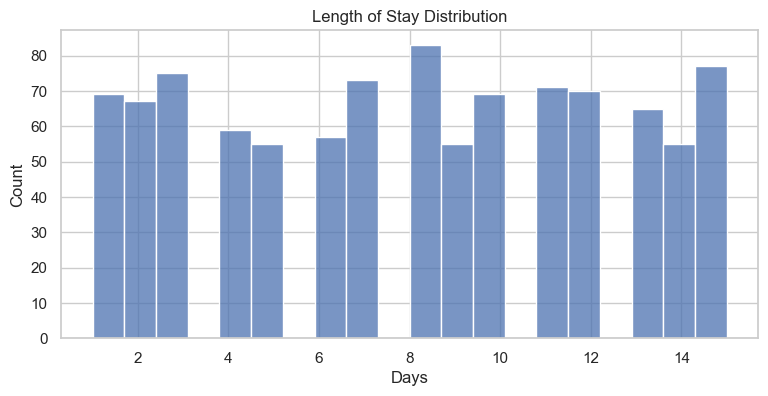

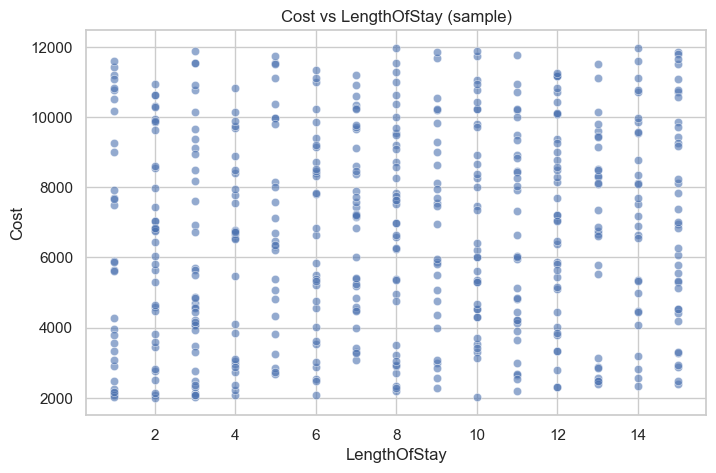

In [17]:
# LengthOfStay distribution and Cost relationship
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(9,4))
sns.histplot(df['LengthOfStay'].dropna(), bins=20)
plt.title('Length of Stay Distribution')
plt.xlabel('Days')
plt.show()

plt.figure(figsize=(8,5))
sample = df.loc[df['Cost'].notna() & df['LengthOfStay'].notna()].sample(min(500, len(df)), random_state=1)
sns.scatterplot(x='LengthOfStay', y='Cost', data=sample, alpha=0.6)
plt.title('Cost vs LengthOfStay (sample)')
plt.ylabel('Cost')
plt.show()

    

In [ ]:
# Readmission rates by InsuranceType and Diagnosis


if 'Readmission30Days' in df.columns:
    readm_by_ins = df.groupby('InsuranceType')['Readmission30Days'].value_counts(normalize=True).unstack().fillna(0)
    display(readm_by_ins)

    readm_by_diag = df.groupby('Diagnosis')['Readmission30Days'].value_counts(normalize=True).unstack().fillna(0)
    display(readm_by_diag.sort_values(by='Yes', ascending=False).head(10))
else:
    print('No Readmission30Days column found')

    

Readmission30Days,No,Yes
InsuranceType,,
Medicaid,0.519841,0.480159
Medicare,0.506173,0.493827
Private,0.457364,0.542636
Self-Pay,0.489879,0.510121


Readmission30Days,No,Yes
Diagnosis,,
Asthma,0.437500,0.562500
Stroke,0.444444,0.555556
Heart Failure,0.457143,0.542857
Infection,0.469565,0.530435
Migraine,0.483516,0.516484
Fracture,0.490000,0.510000
Diabetes,0.490196,0.509804
Hypertension,0.500000,0.500000
Pneumonia,0.577320,0.422680


In [25]:
# Outcomes by age group

import pandas as pd

# This cell assumes `df` already exists from prior cells; if not, run the data-load cell.

df['age_group'] = pd.cut(df['Age'].astype(float), bins=[0,18,35,50,65,80,120], labels=['0-18','19-35','36-50','51-65','66-80','80+'])
outcome_by_age = df.groupby('age_group')['Outcome'].value_counts(normalize=True).unstack().fillna(0)
display(outcome_by_age)

    

C:\Users\rubya\AppData\Local\Temp\ipykernel_26052\1225618597.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  outcome_by_age = df.groupby('age_group')['Outcome'].value_counts(normalize=True).unstack().fillna(0)


Outcome,Deceased,Improved,Recovered,Transferred
age_group,,,,
0-18,0.253886,0.259067,0.253886,0.233161
19-35,0.241758,0.252747,0.225275,0.280220
36-50,0.212121,0.212121,0.272727,0.303030
51-65,0.236364,0.309091,0.236364,0.218182
66-80,0.245989,0.229947,0.310160,0.213904
80+,0.305556,0.277778,0.231481,0.185185


## Notes
- This notebook provides reproducible EDA. Run all cells to generate plots and tables.

## Dashboard-Style Analytics (Python equivalent of Power BI)

Below are interactive visualizations and KPIs mimicking the Power BI Healthcare Patient Analytics Dashboard.

In [ ]:
# Key Performance Indicators (KPIs)

# Ensure data is ready
if 'df' in globals() and len(df) > 0:
    total_visits = len(df)
    avg_cost = df['Cost'].mean() if 'Cost' in df.columns else 0
    avg_los = df['LengthOfStay'].mean() if 'LengthOfStay' in df.columns else 0
    
    # Adult vs Pediatric (assuming Age < 18 is pediatric)
    pediatric_count = (df['Age'] < 18).sum() if 'Age' in df.columns else 0
    adult_count = total_visits - pediatric_count
    
    print(f"{'='*50}")
    print(f"  HEALTHCARE PATIENT ANALYTICS - KPI SUMMARY")
    print(f"{'='*50}")
    print(f"Total Visits:              {total_visits:,}")
    print(f"Average Cost:              ${avg_cost:,.2f}")
    print(f"Average Length of Stay:    {avg_los:.1f} days")
    print(f"Adult Count:               {adult_count:,}")
    print(f"Pediatric Count:           {pediatric_count:,}")
    print(f"{'='*50}\n")
else:
    print("Load data first using the data-load cell")


In [ ]:
# Monthly Visit Trend by Hospital System

if 'df' in globals() and 'AdmissionDate' in df.columns and 'Hospital' in df.columns:
    df_plot = df.dropna(subset=['AdmissionDate', 'Hospital']).copy()
    df_plot['YearMonth'] = df_plot['AdmissionDate'].dt.to_period('M')
    
    monthly_trend = df_plot.groupby(['YearMonth', 'Hospital']).size().unstack(fill_value=0)
    
    plt.figure(figsize=(12, 6))
    monthly_trend.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='Set2')
    plt.title('Monthly Visit Trend by Hospital System', fontsize=14, fontweight='bold')
    plt.xlabel('Month', fontsize=11)
    plt.ylabel('Number of Visits', fontsize=11)
    plt.legend(title='Hospital', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Ensure AdmissionDate and Hospital columns exist and data is loaded")


In [ ]:
# Quarterly Average Treatment Cost by Hospital

if 'df' in globals() and 'AdmissionDate' in df.columns and 'Cost' in df.columns and 'Hospital' in df.columns:
    df_plot = df.dropna(subset=['AdmissionDate', 'Cost', 'Hospital']).copy()
    df_plot['Quarter'] = df_plot['AdmissionDate'].dt.to_period('Q')
    
    quarterly_cost = df_plot.groupby(['Quarter', 'Hospital'])['Cost'].mean().unstack()
    
    plt.figure(figsize=(12, 6))
    for hospital in quarterly_cost.columns:
        plt.plot(quarterly_cost.index.astype(str), quarterly_cost[hospital], marker='o', label=hospital, linewidth=2)
    
    plt.title('Quarterly Average Treatment Cost by Hospital', fontsize=14, fontweight='bold')
    plt.xlabel('Quarter', fontsize=11)
    plt.ylabel('Average Cost ($)', fontsize=11)
    plt.legend(title='Hospital', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Ensure AdmissionDate, Cost, and Hospital columns exist and data is loaded")


In [ ]:
# Patient Demographics by Hospital (Adult vs Pediatric)

if 'df' in globals() and 'Hospital' in df.columns and 'Age' in df.columns:
    df_plot = df.dropna(subset=['Hospital', 'Age']).copy()
    df_plot['PatientType'] = df_plot['Age'].apply(lambda x: 'Pediatric' if x < 18 else 'Adult')
    
    demo = df_plot.groupby(['Hospital', 'PatientType']).size().unstack(fill_value=0)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    demo.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'], width=0.7)
    
    plt.title('Patient Demographics by Hospital', fontsize=14, fontweight='bold')
    plt.xlabel('Hospital', fontsize=11)
    plt.ylabel('Patient Count', fontsize=11)
    plt.legend(title='Patient Type', fontsize=10)
    plt.xticks(rotation=45, ha='right')
    
    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', fontsize=9)
    
    plt.tight_layout()
    plt.show()
else:
    print("Ensure Hospital and Age columns exist and data is loaded")


In [ ]:
# Department-Level Visit Distribution by Hospital (Stacked Bar)

if 'df' in globals() and 'Hospital' in df.columns and 'Department' in df.columns:
    df_plot = df.dropna(subset=['Hospital', 'Department']).copy()
    
    dept_dist = df_plot.groupby(['Hospital', 'Department']).size().unstack(fill_value=0)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    dept_dist.plot(kind='bar', stacked=True, ax=ax, colormap='Set3', width=0.7)
    
    plt.title('Department-Level Visit Distribution by Hospital', fontsize=14, fontweight='bold')
    plt.xlabel('Hospital', fontsize=11)
    plt.ylabel('Number of Visits', fontsize=11)
    plt.legend(title='Department', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=1)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Ensure Hospital and Department columns exist and data is loaded")


## Summary

This notebook now includes both exploratory analysis and dashboard-style visualizations equivalent to your Power BI report:
- **KPIs**: Total visits, average cost, average LOS, adult/pediatric breakdown
- **Trends**: Monthly visits by hospital, quarterly cost trends
- **Demographics**: Patient type distribution, department utilization by hospital

To enhance further: export plots as images, add `plotly` for interactive dashboards, or build a simple Streamlit app for real-time exploration.